# Diabetes Analysis (NIDDK Dataset)


## Introduction

This notebook explores the Diabetes dataset provided by the National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK).

The objective of this analysis is to understand the relationship between diagnostic health measurements and the occurrence of diabetes.
The analysis focuses on data cleaning, exploratory data analysis (EDA) and extracting meaningful insights from the dataset.

Columns meanings

**Pregnancies:** Number of times pregnant  
**Glucose:** Plasma glucose concentration a 2 hours in an oral glucose tolerance test  
**BloodPressure:** Diastolic blood pressure (mm Hg)  
**SkinThickness:** Triceps skin fold thickness (mm)  
**Insulin:** 2-Hour serum insulin (mu U/ml)  
**BMI:** Body mass index (weight in kg/(height in m)^2)  
**DiabetesPedigreeFunction:** Diabetes pedigree function  
**Age:** Age (years)  
**Outcome:** Class variable (0 or 1)  

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df_original = pd.read_csv("data/diabetes.csv")
df = df_original.copy()
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Dataset Description

All patients in this dataset are female and at least 21 years old.
The dataset contains medical predictor variables and one target variable (`Outcome`),
which indicates whether the patient has diabetes (1) or not (0).


In [3]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


print(f'Shape     :  {df.shape}\n'
      f'Size      :  {df.size}\n' 
      f'Dimension :  {df.ndim}\n'
     )

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df['Outcome'].value_counts(normalize=True)


Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

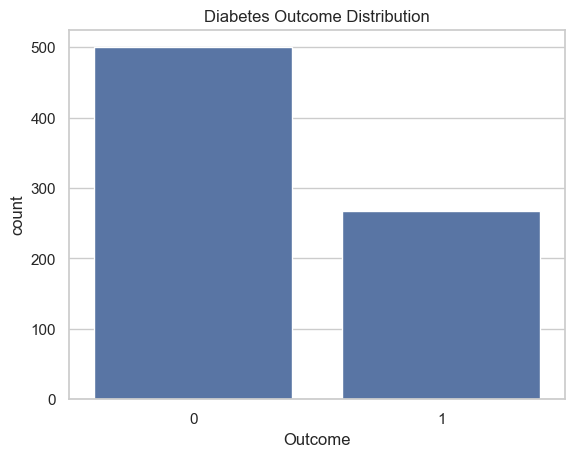

In [7]:
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome Distribution")
plt.show()

The dataset shows a moderate class imbalance, with a higher number of non-diabetic
patients compared to diabetic patients.


## Data Cleaning

### Handling Missing Values

Certain medical measurements such as glucose, blood pressure, insulin, and BMI
cannot be zero in real-world scenarios. In this dataset, zero values indicate
missing measurements and must be handled appropriately.


In [8]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

In [9]:
df.isna().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [10]:
for col in cols_with_zero:
    df[col] = df[col].fillna(df[col].median())


In [11]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## EDA (Exploratory Data Analysis)

### Feature Distributions

Understanding individual feature distributions helps identify skewness
and potential outliers.


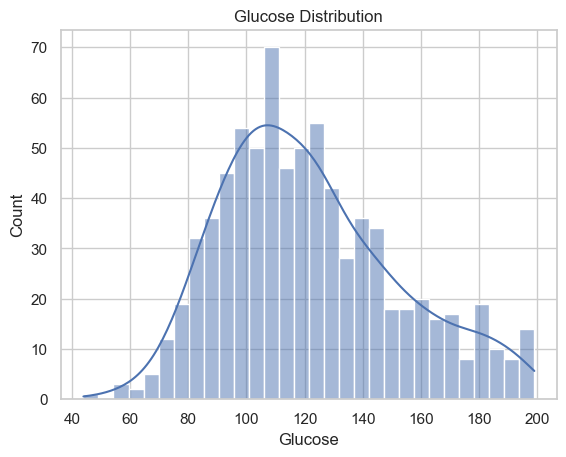

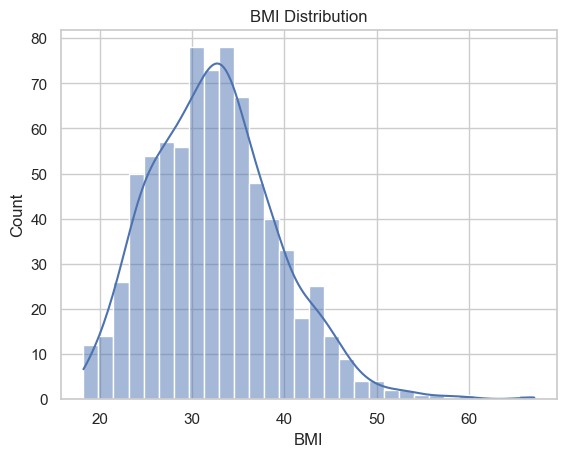

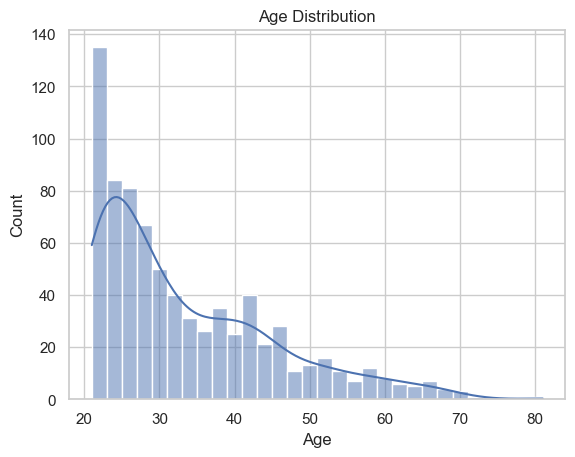

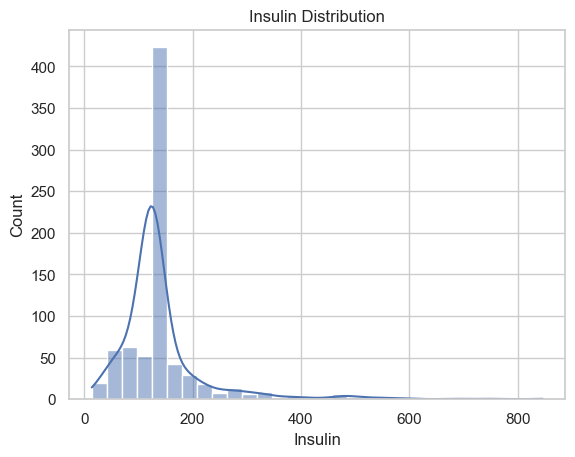

In [12]:
features = ['Glucose', 'BMI', 'Age', 'Insulin']

for feature in features:
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f"{feature} Distribution")
    plt.show()


## Bivariate Analysis(Feature vs Outcome)

### Relationship Between Features and Diabetes


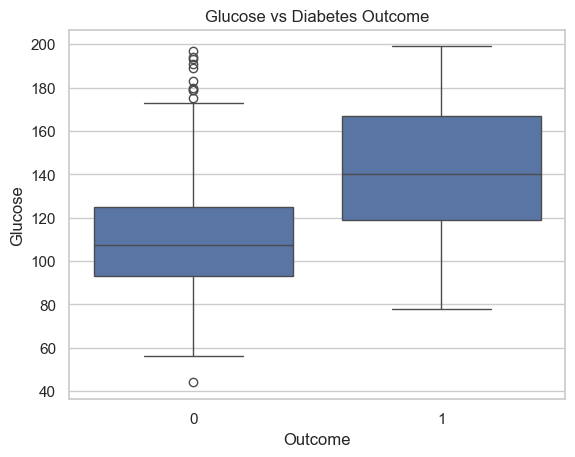

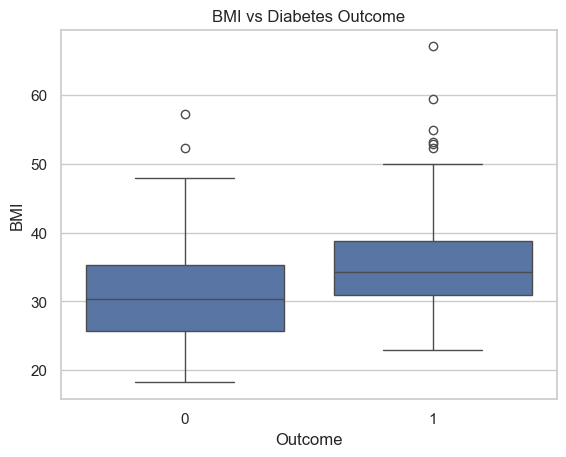

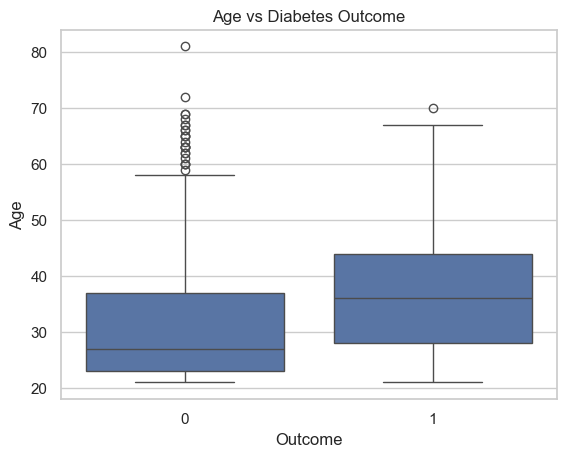

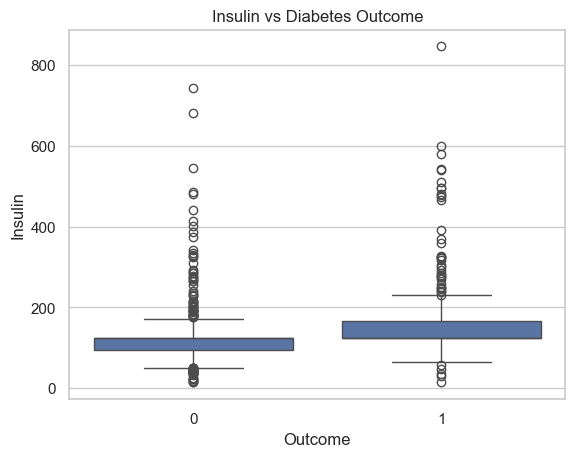

In [13]:
features = ['Glucose', 'BMI', 'Age', 'Insulin']

for feature in features:
    sns.boxplot(x='Outcome', y=feature, data=df)
    plt.title(f"{feature} vs Diabetes Outcome")
    plt.show()


Glucose shows the strongest separation between diabetic and non-diabetic patients.
BMI and Age also demonstrate noticeable differences across outcomes.


## Correlation Analysis

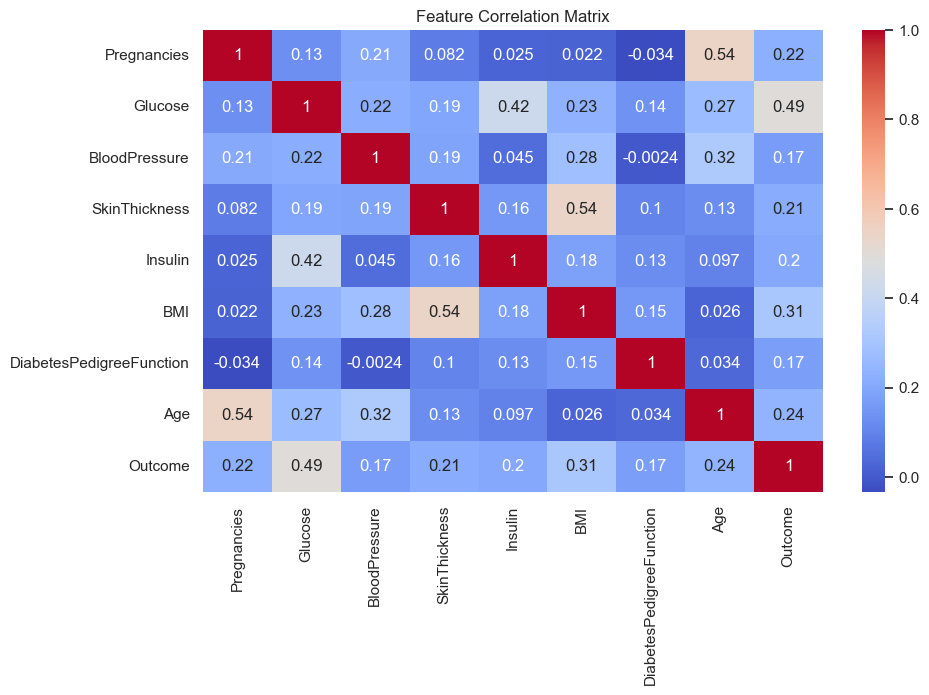

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

Glucose exhibits the highest correlation with diabetes outcome,
followed by BMI and Age. Insulin shows variability due to measurement noise.


## Statistical Summary by Outcome

In [15]:
df.groupby("Outcome").mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,127.792000,30.885600,0.429734,31.190000
1,4.865672,142.130597,75.123134,31.686567,164.701493,35.383582,0.550500,37.067164


On average, patients diagnosed with diabetes have higher glucose levels,
higher BMI, and are older compared to non-diabetic patients.


## Key Insights

- Glucose concentration is the strongest indicator of diabetes.
- Higher BMI is associated with increased diabetes risk.
- Older patients show a higher likelihood of diabetes.
- Genetic predisposition (Diabetes Pedigree Function) plays a moderate role.

## Conclusion

This analysis explored diagnostic health indicators associated with diabetes
using the NIDDK dataset. The findings highlight glucose, BMI, and age as
key contributors to diabetes risk. These insights provide a strong foundation
for building predictive machine learning models in future work.


## Next Steps

- Feature scaling and normalization
- Machine learning models (Logistic Regression, Random Forest)
- Model evaluation using ROC-AUC
- Feature importance and explainability
